In [1]:
import json
import numpy as np
import os
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import Rotator

import ot 
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform

from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import MDS
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.metrics import classification_report, accuracy_score
from scipy.spatial.distance import pdist, squareform
from factor_analyzer import Rotator
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold

pd.set_option('display.max_columns', None)

In [2]:
appraisal_columns = ["pleasantness", "enjoyment", "consider", "attention", "understand", "control-situational", "control-self", "control-other", "certainty", "problem", "obstacle", "legitimacy-cheated", "legitimacy-fair", "responsibility-self", "responsibility-other", "exert", "effort"]
def process_single_output(output_text): 
    if not isinstance(output_text, str): 
        output_text = output_text["content"]
    
    output_text = output_text.replace("\n", "")
    output_text = output_text.replace("`", "")
    output_text = output_text.replace("json", "")
    # output_text = output_text.replace("JSON", "")
    # output_text = output_text.replace(" ", "")

    if "[/INST]" in output_text: 
        output_text = output_text.split("[/INST]")[1] # case-by-case handling for mistral

    if "Here is the response" in output_text: 
        output_text = output_text.split("Here is the response")[1]
    
    if "{" in output_text: 
        response = output_text.split("{")[1] # considering whatever comes after the first JSON
        response = response.split("}")[0]
        response = "{" + response + "}"
        response_json = ""
        try: 
            response_json = json.loads(response)
        except Exception as e: 
            # print(f"Could not load JSON accurately for model output = {response}")
            return None
        
        if not response_json:
            return None
        
        if "Question 1" not in response_json or "Question 2" not in response_json: 
            # print(f"Invalid keys found in response JSON = {response_json}")
            return None
        
        q1 = response_json["Question 1"]
        q2 = response_json["Question 2"]
        return q1, q2

    return None

In [3]:
def create_appraisal_emotion_df(file): 
    appraisal_dict = {
        "pleasantness": [],
        "enjoyment": [],
        "consider": [],
        "attention": [],
        "understand": [],
        "control-situational": [],
        "control-self": [],
        "control-other": [],
        "certainty": [],
        "problem": [],
        "obstacle": [],
        "legitimacy-cheated": [],
        "legitimacy-fair": [],
        "responsibility-self": [],
        "responsibility-other": [],
        "exert": [],
        "effort": [],
        "emotion_label": []
    }

    with open(file, "r") as f: 
        count = 0
        null_count = 0
        invalid_count = 0 
        for line in f.readlines():
            # print(line) 
            curr_json = json.loads(line)
            rating = None
            if curr_json and curr_json["output"]:
                processed_output = process_single_output(curr_json["output"])
            
            
                if processed_output: 
                    a1, a2 = processed_output
                    if isinstance(a2, list):
                        if len(a2) == 2: 
                            rating = a2[1]

            if not rating: 
                null_count += 1

            curr_dim = curr_json["id"].split("_")[-1]

            try:
                rating = int(rating)
            except: 
                invalid_count += 1
                rating = None

            appraisal_dict[curr_dim].append(rating)
            if count % 17 == 0:
                if "high" in file or "low" in file:
                    appraisal_dict["emotion_label"].append(curr_json["id"].split("_")[3])
                else: 
                    appraisal_dict["emotion_label"].append(curr_json["id"].split("_")[1])
            count += 1
        # for key, value in appraisal_dict.items(): 
            # print(f"{key}: {len(appraisal_dict[key])}")
        print(f"Null Count = {null_count} out of 4658 responses. Percentage = {float(null_count)/4658}")
        print(f"Invalid Count = {invalid_count} out of 4658 responses. Percentage = {float(invalid_count)/4658}")

    df = pd.DataFrame(appraisal_dict)
    df = df.fillna(0)
    df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
    df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)
    return df

In [4]:
gpt_vanilla_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gpt_with_emotion_vanilla.jsonl")
gpt_ahigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_agreeableness_high.jsonl")
gpt_alow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_agreeableness_low.jsonl")
gpt_chigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_conscientiousness_high.jsonl")
gpt_clow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_conscientiousness_low.jsonl")
gpt_ehigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_extraversion_high.jsonl")
gpt_elow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_extraversion_low.jsonl")
gpt_nhigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_neuroticism_high.jsonl")
gpt_nlow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_neuroticism_low.jsonl")
gpt_ohigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_openness_high.jsonl")
gpt_olow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gpt_with_emotion_openness_low.jsonl")


Null Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Invalid Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Invalid Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Invalid Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Invalid Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Null Count = 5 out of 4658 responses. Percentage = 0.0010

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


Null Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Invalid Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Null Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Invalid Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Null Count = 3 out of 4658 responses. Percentage = 0.0006440532417346501
Invalid Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007


In [5]:
gemini_vanilla_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gemini_2_5_flash_with_emotion_vanilla.jsonl")
gemini_ahigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_agreeableness_high.jsonl")
gemini_alow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_agreeableness_low.jsonl")
gemini_chigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_conscientiousness_high.jsonl")
gemini_clow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_conscientiousness_low.jsonl")
gemini_ehigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_extraversion_high.jsonl")
gemini_elow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_extraversion_low.jsonl")
gemini_ohigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_openness_high.jsonl")
gemini_olow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_openness_low.jsonl")
gemini_nhigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_neuroticism_high.jsonl")
gemini_nlow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_neuroticism_low.jsonl")

Null Count = 8 out of 4658 responses. Percentage = 0.0017174753112924003
Invalid Count = 8 out of 4658 responses. Percentage = 0.0017174753112924003
Null Count = 8 out of 4658 responses. Percentage = 0.0017174753112924003
Invalid Count = 8 out of 4658 responses. Percentage = 0.0017174753112924003
Null Count = 43 out of 4658 responses. Percentage = 0.00923142979819665
Invalid Count = 43 out of 4658 responses. Percentage = 0.00923142979819665
Null Count = 10 out of 4658 responses. Percentage = 0.0021468441391155
Invalid Count = 9 out of 4658 responses. Percentage = 0.0019321597252039502
Null Count = 23 out of 4658 responses. Percentage = 0.00493774151996565
Invalid Count = 20 out of 4658 responses. Percentage = 0.004293688278231
Null Count = 6 out of 4658 responses. Percentage = 0.0012881064834693002
Invalid Count = 6 out of 4658 responses. Percentage = 0.0012881064834693002


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


Null Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Invalid Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Null Count = 20 out of 4658 responses. Percentage = 0.004293688278231
Invalid Count = 20 out of 4658 responses. Percentage = 0.004293688278231
Null Count = 21 out of 4658 responses. Percentage = 0.004508372692142551
Invalid Count = 20 out of 4658 responses. Percentage = 0.004293688278231
Null Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Invalid Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Null Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Invalid Count = 11 out of 4658 responses. Percentage = 0.0023615285530270503


In [6]:
phi_vanilla_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/phi_4_with_emotion_vanilla.jsonl")
phi_ahigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_agreeableness_high.jsonl")
phi_alow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_agreeableness_low.jsonl")
phi_chigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_conscientiousness_high.jsonl")
phi_clow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_conscientiousness_low.jsonl")
phi_ehigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_extraversion_high.jsonl")
phi_elow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_extraversion_low.jsonl")
phi_nhigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_neuroticism_high.jsonl")
phi_nlow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_neuroticism_low.jsonl")
phi_ohigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_openness_high.jsonl")
phi_olow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/phi_with_emotion_openness_low.jsonl")

Null Count = 4 out of 4658 responses. Percentage = 0.0008587376556462001
Invalid Count = 4 out of 4658 responses. Percentage = 0.0008587376556462001
Null Count = 8 out of 4658 responses. Percentage = 0.0017174753112924003
Invalid Count = 6 out of 4658 responses. Percentage = 0.0012881064834693002
Null Count = 1365 out of 4658 responses. Percentage = 0.2930442249892658
Invalid Count = 1363 out of 4658 responses. Percentage = 0.29261485616144267
Null Count = 5 out of 4658 responses. Percentage = 0.00107342206955775
Invalid Count = 5 out of 4658 responses. Percentage = 0.00107342206955775
Null Count = 3 out of 4658 responses. Percentage = 0.0006440532417346501
Invalid Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Null Count = 3 out of 4658 responses. Percentage = 0.0006440532417346501
Invalid Count = 2 out of 4658 responses. Percentage = 0.00042936882782310007
Null Count = 9 out of 4658 responses. Percentage = 0.0019321597252039502
Invalid Count = 8 out of 4658 resp

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


Null Count = 4 out of 4658 responses. Percentage = 0.0008587376556462001
Invalid Count = 4 out of 4658 responses. Percentage = 0.0008587376556462001
Null Count = 7 out of 4658 responses. Percentage = 0.0015027908973808501
Invalid Count = 7 out of 4658 responses. Percentage = 0.0015027908973808501
Null Count = 3 out of 4658 responses. Percentage = 0.0006440532417346501
Invalid Count = 3 out of 4658 responses. Percentage = 0.0006440532417346501
Null Count = 5 out of 4658 responses. Percentage = 0.00107342206955775
Invalid Count = 5 out of 4658 responses. Percentage = 0.00107342206955775


In [7]:
llama_vanilla_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_vanilla.jsonl")
llama_ahigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_agreeableness_high.jsonl")
llama_alow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_agreeableness_low.jsonl")
llama_chigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_conscientiousness_high.jsonl")
llama_clow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_conscientiousness_low.jsonl")
llama_ehigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_extraversion_high.jsonl")
llama_elow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_extraversion_low.jsonl")
llama_nhigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_neuroticism_high.jsonl")
llama_nlow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_neuroticism_low.jsonl")
llama_ohigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_openness_high.jsonl")
llama_olow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/llama_with_emotion_openness_low.jsonl")

Null Count = 827 out of 4658 responses. Percentage = 0.17754401030485187
Invalid Count = 826 out of 4658 responses. Percentage = 0.17732932589094033
Null Count = 467 out of 4658 responses. Percentage = 0.10025762129669386
Invalid Count = 467 out of 4658 responses. Percentage = 0.10025762129669386
Null Count = 468 out of 4658 responses. Percentage = 0.1004723057106054
Invalid Count = 465 out of 4658 responses. Percentage = 0.09982825246887075
Null Count = 201 out of 4658 responses. Percentage = 0.043151567196221555
Invalid Count = 200 out of 4658 responses. Percentage = 0.042936882782310004


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


Null Count = 332 out of 4658 responses. Percentage = 0.07127522541863461
Invalid Count = 332 out of 4658 responses. Percentage = 0.07127522541863461
Null Count = 928 out of 4658 responses. Percentage = 0.1992271361099184
Invalid Count = 928 out of 4658 responses. Percentage = 0.1992271361099184
Null Count = 787 out of 4658 responses. Percentage = 0.16895663374838987
Invalid Count = 786 out of 4658 responses. Percentage = 0.1687419493344783
Null Count = 273 out of 4658 responses. Percentage = 0.058608844997853154
Invalid Count = 273 out of 4658 responses. Percentage = 0.058608844997853154
Null Count = 775 out of 4658 responses. Percentage = 0.16638042078145127
Invalid Count = 775 out of 4658 responses. Percentage = 0.16638042078145127
Null Count = 1304 out of 4658 responses. Percentage = 0.27994847574066123
Invalid Count = 1303 out of 4658 responses. Percentage = 0.2797337913267497
Null Count = 816 out of 4658 responses. Percentage = 0.17518248175182483
Invalid Count = 813 out of 4658 r

In [8]:
ds_vanilla_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/deepseek_r1_with_emotion_vanilla.jsonl")
ds_ahigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/deepseek_with_emotion_agreeableness_high.jsonl")
ds_alow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/deepseek_with_emotion_agreeableness_low.jsonl")
ds_chigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/deepseek_with_emotion_conscientiousness_high.jsonl")
ds_clow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/deepseek_with_emotion_conscientiousness_low.jsonl")
ds_ehigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/deepseek_with_emotion_extraversion_high.jsonl")
ds_elow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/deepseek_with_emotion_extraversion_low.jsonl")
ds_nhigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_neuroticism_high.jsonl")
ds_nlow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_neuroticism_low.jsonl")
ds_ohigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_openness_high.jsonl")
ds_olow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/gemini_with_emotion_openness_low.jsonl")

Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 0 out of 4658 responses. Percentage = 0.0
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 1 out of 4658 responses. Percentage = 0.00021468441391155003
Invalid Count = 0 out of 4658 responses. Percentage = 0.0
Null Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Invalid Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


Null Count = 15 out of 4658 responses. Percentage = 0.0032202662086732504
Invalid Count = 11 out of 4658 responses. Percentage = 0.0023615285530270503
Null Count = 20 out of 4658 responses. Percentage = 0.004293688278231
Invalid Count = 20 out of 4658 responses. Percentage = 0.004293688278231
Null Count = 21 out of 4658 responses. Percentage = 0.004508372692142551
Invalid Count = 20 out of 4658 responses. Percentage = 0.004293688278231


In [9]:
qwq_vanilla_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/qwq_with_emotion_vanilla.jsonl")
qwq_ahigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_agreeableness_high.jsonl")
qwq_alow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_agreeableness_low.jsonl")
qwq_chigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_conscientiousness_high.jsonl")
qwq_clow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_conscientiousness_low.jsonl")
qwq_ehigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_extraversion_high.jsonl")
qwq_elow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_extraversion_low.jsonl")
qwq_nhigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_neuroticism_high.jsonl")
qwq_nlow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_neuroticism_low.jsonl")
qwq_ohigh_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_openness_high.jsonl")
qwq_olow_df = create_appraisal_emotion_df("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/personality/qwq_with_emotion_openness_low.jsonl")

Null Count = 113 out of 4658 responses. Percentage = 0.024259338772005153
Invalid Count = 112 out of 4658 responses. Percentage = 0.024044654358093602
Null Count = 149 out of 4658 responses. Percentage = 0.03198797767282095
Invalid Count = 149 out of 4658 responses. Percentage = 0.03198797767282095


/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:66: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3394398936.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, str) and x.isdigit() else x)


Null Count = 365 out of 4658 responses. Percentage = 0.07835981107771575
Invalid Count = 365 out of 4658 responses. Percentage = 0.07835981107771575
Null Count = 100 out of 4658 responses. Percentage = 0.021468441391155002
Invalid Count = 100 out of 4658 responses. Percentage = 0.021468441391155002
Null Count = 186 out of 4658 responses. Percentage = 0.0399313009875483
Invalid Count = 185 out of 4658 responses. Percentage = 0.03971661657363675
Null Count = 123 out of 4658 responses. Percentage = 0.02640618291112065
Invalid Count = 123 out of 4658 responses. Percentage = 0.02640618291112065
Null Count = 196 out of 4658 responses. Percentage = 0.0420781451266638
Invalid Count = 195 out of 4658 responses. Percentage = 0.04186346071275225
Null Count = 158 out of 4658 responses. Percentage = 0.0339201373980249
Invalid Count = 156 out of 4658 responses. Percentage = 0.03349076857020181
Null Count = 120 out of 4658 responses. Percentage = 0.025762129669386003
Invalid Count = 119 out of 4658 r

In [10]:
persona_dfs_qwq = [qwq_vanilla_df, qwq_ahigh_df, qwq_alow_df, qwq_chigh_df, qwq_clow_df, qwq_ehigh_df, qwq_elow_df, qwq_nhigh_df, qwq_nlow_df, qwq_ohigh_df, qwq_olow_df]

In [11]:
# comparison using the MMD metric test 
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

def mmd_rbf(X, Y, gamma=1.0):
    """Compute unbiased MMD^2 between two sets X and Y."""
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    n = len(X)
    m = len(Y)

    # unbiased estimator
    term_xx = (np.sum(Kxx) - np.sum(np.diag(Kxx))) / (n*(n-1))
    term_yy = (np.sum(Kyy) - np.sum(np.diag(Kyy))) / (m*(m-1))
    term_xy = np.sum(Kxy) / (n*m)

    return term_xx + term_yy - 2*term_xy

def mmd_test(X, Y, num_perm=2000, gamma=1.0):
    """Return (observed MMD, p-value) using permutation test."""
    observed = mmd_rbf(X, Y, gamma=gamma)
    Z = np.vstack([X, Y])
    n = len(X)

    perm_stats = []
    for _ in range(num_perm):
        perm = np.random.permutation(len(Z))
        Xp = Z[perm[:n]]
        Yp = Z[perm[n:]]
        perm_stats.append(mmd_rbf(Xp, Yp, gamma=gamma))

    p_value = np.mean(np.array(perm_stats) >= observed)
    return observed, p_value

def compute_mmd_vs_vanilla(persona_dfs, persona_names=["Vanilla", "A-High", "A-Low", "C-High", "C-Low", "E-High", "E-Low", "N-High", "N-Low", "O-High", "O-Low"], num_perm=2000, gamma=1.0):
    """
    Compute MMD + p-value between vanilla persona (first df)
    and all other personas, using full appraisal distributions.
    
    persona_dfs: list of pandas DataFrames
                 [vanilla_df, persona_a_df, persona_b_df, ...]
    persona_names: list of names, same length as persona_dfs.
                   If None, names are auto-generated.
    num_perm: number of permutations for the MMD test
    gamma: RBF kernel parameter used in mmd_test
    """
    if persona_names is None:
        persona_names = [f"persona_{i}" for i in range(len(persona_dfs))]
    
    # Assume all dfs share the same columns
    all_cols = persona_dfs[0].columns
    appraisal_dims = [c for c in all_cols if c.lower() != "emotion_label"]  # drop label col
    
    # Vanilla = first persona
    vanilla_df = persona_dfs[0]
    X_vanilla = vanilla_df[appraisal_dims].to_numpy(dtype=float)
    
    rows = []
    for idx, (name, df) in enumerate(zip(persona_names, persona_dfs)):
        if idx == 0:
            # skip vanilla vs vanilla
            continue
        if not isinstance(df, pd.DataFrame): 
            # df not available yet 
            continue
        
        X_persona = df[appraisal_dims].to_numpy().astype(np.float64)
        
        # Optionally handle empty dfs:
        if X_vanilla.shape[0] == 0 or X_persona.shape[0] == 0:
            stat, p = np.nan, np.nan
        else:
            stat, p = mmd_test(X_vanilla, X_persona, num_perm=num_perm, gamma=gamma)
        
        rows.append({
            "baseline": persona_names[0],
            "persona": name,
            "MMD": stat,
            "p_value": p,
            "n_vanilla": X_vanilla.shape[0],
            "n_persona": X_persona.shape[0],
        })
    
    return pd.DataFrame(rows)

In [12]:
mmd_gpt = compute_mmd_vs_vanilla([gpt_vanilla_df, gpt_ahigh_df, gpt_alow_df, gpt_chigh_df, gpt_clow_df, gpt_ehigh_df, gpt_elow_df, gpt_nhigh_df, gpt_nlow_df, gpt_ohigh_df, gpt_olow_df])

# Model responses are significantly different for low agreeableness, high conscientiousness, low conscientiousness, low extraversion, low openness

In [13]:
mmd_gpt

,baseline,persona,MMD,p_value,n_vanilla,n_persona
0,Vanilla,A-High,-1.743221e-07,0.6020,274,274
1,Vanilla,A-Low,4.109545e-06,0.0000,274,274
2,Vanilla,C-High,2.874742e-06,0.0465,274,274
3,Vanilla,C-Low,1.013117e-06,0.0000,274,274
4,Vanilla,E-High,-3.685788e-06,0.7435,274,274
5,Vanilla,E-Low,4.741383e-06,0.0200,274,274
6,Vanilla,N-High,2.771689e-07,0.2390,274,274
7,Vanilla,N-Low,2.662715e-06,0.1335,274,274
8,Vanilla,O-High,-5.702851e-06,0.9405,274,274
9,Vanilla,O-Low,1.463835e-06,0.0000,274,274


In [200]:
gpt_dims = set(["a-low", "c-high", "c-low", "e-low", "o-low"])

In [23]:
# gemini
mmd_gemini = compute_mmd_vs_vanilla([gemini_vanilla_df, gemini_ahigh_df, gemini_alow_df, gemini_chigh_df, gemini_clow_df, gemini_ehigh_df, gemini_elow_df, gemini_nhigh_df, gemini_nlow_df, gemini_ohigh_df, gemini_olow_df])

# significant difference for: high agreeableness, low agreeableness, high conscientiousness, low extraversion, high neuroticism, low openness

In [24]:
mmd_gemini

,baseline,persona,MMD,p_value,n_vanilla,n_persona
0,Vanilla,A-High,3.753360e-04,0.0000,274,274
1,Vanilla,A-Low,5.883238e-06,0.0000,274,274
2,Vanilla,C-High,9.599245e-05,0.0000,274,274
3,Vanilla,C-Low,4.939995e-06,0.0000,274,274
4,Vanilla,E-High,3.249966e-05,0.1385,274,274
5,Vanilla,E-Low,6.251084e-06,0.0115,274,274
6,Vanilla,N-High,1.340457e-05,0.0000,274,274
7,Vanilla,N-Low,3.554651e-06,0.2545,274,274
8,Vanilla,O-High,7.555251e-07,0.4475,274,274
9,Vanilla,O-Low,9.425898e-06,0.0000,274,274


In [203]:
gemini_dims = set(["a-high", "a-low", "c-high", "c-low", "e-low", "n-high", "o-low"])

In [14]:
# phi 
mmd_phi = compute_mmd_vs_vanilla([phi_vanilla_df, phi_ahigh_df, phi_alow_df, phi_chigh_df, phi_clow_df, phi_ehigh_df, phi_elow_df, phi_nhigh_df, phi_nlow_df, phi_ohigh_df, phi_olow_df])
# significant differences for low agreeableness, low conscientiousness, low extraversion, high neuroticism, low neuroticism, high openness

In [15]:
mmd_phi

,baseline,persona,MMD,p_value,n_vanilla,n_persona
0,Vanilla,A-High,1.607267e-06,0.2155,274,274
1,Vanilla,A-Low,6.679701e-07,0.0000,274,274
2,Vanilla,C-High,7.450182e-07,0.2865,274,274
3,Vanilla,C-Low,7.019970e-07,0.0000,274,274
4,Vanilla,E-High,9.931448e-07,0.3525,274,274
5,Vanilla,E-Low,1.044558e-06,0.0010,274,274
6,Vanilla,N-High,7.263120e-07,0.0005,274,274
7,Vanilla,N-Low,1.259682e-06,0.0425,274,274
8,Vanilla,O-High,-1.289955e-08,0.5050,274,274
9,Vanilla,O-Low,6.643783e-07,0.0000,274,274


In [205]:
phi_dims = set(["a-low", "c-low", "e-low", "n-high", "o-low"])

In [16]:
# llama
mmd_llama = compute_mmd_vs_vanilla([llama_vanilla_df, llama_ahigh_df, llama_alow_df, llama_chigh_df, llama_clow_df, llama_ehigh_df, llama_elow_df, llama_nhigh_df, llama_nlow_df, llama_ohigh_df, llama_olow_df])

In [17]:
mmd_llama

,baseline,persona,MMD,p_value,n_vanilla,n_persona
0,Vanilla,A-High,2.019383e-11,0.2660,274,274
1,Vanilla,A-Low,9.704572e-13,0.0410,274,274
2,Vanilla,C-High,9.324284e-09,0.0230,274,274
3,Vanilla,C-Low,1.207516e-11,0.0295,274,274
4,Vanilla,E-High,1.390663e-12,0.2175,274,274
5,Vanilla,E-Low,-7.246495e-12,0.5480,274,274
6,Vanilla,N-High,5.285755e-09,0.0160,274,274
7,Vanilla,N-Low,-9.387801e-12,0.8750,274,274
8,Vanilla,O-High,9.745191e-13,0.0225,274,274
9,Vanilla,O-Low,8.927187e-13,0.0550,274,274


In [207]:
llama_dims = set(["a-low", "c-high", "c-low", "n-high", "o-high"])

In [18]:
mmd_ds = compute_mmd_vs_vanilla([ds_vanilla_df, ds_ahigh_df, ds_alow_df, ds_chigh_df, ds_clow_df, ds_ehigh_df, ds_elow_df, ds_nhigh_df, ds_nlow_df, ds_ohigh_df, ds_olow_df])

In [19]:
mmd_ds

,baseline,persona,MMD,p_value,n_vanilla,n_persona
0,Vanilla,A-High,0.000020,0.0010,274,274
1,Vanilla,A-Low,0.000003,0.0000,274,274
2,Vanilla,C-High,0.000006,0.0080,274,274
3,Vanilla,C-Low,0.000005,0.0000,274,274
4,Vanilla,E-High,0.000007,0.0005,274,274
5,Vanilla,E-Low,0.000003,0.0085,274,274
6,Vanilla,N-High,0.000013,0.0000,274,274
7,Vanilla,N-Low,0.000007,0.0010,274,274
8,Vanilla,O-High,0.000008,0.0000,274,274
9,Vanilla,O-Low,0.000009,0.0000,274,274


In [209]:
ds_dims = set(["a-high", "a-low", "c-high", "c-low", "e-high", "e-low", "n-high", "n-low", "o-high", "o-low"])

In [20]:
mmd_qwq = compute_mmd_vs_vanilla(persona_dfs_qwq)

In [21]:
mmd_qwq

,baseline,persona,MMD,p_value,n_vanilla,n_persona
0,Vanilla,A-High,-8.463478e-08,0.7685,274,274
1,Vanilla,A-Low,2.715951e-08,0.0000,274,274
2,Vanilla,C-High,5.833421e-08,0.0870,274,274
3,Vanilla,C-Low,2.733302e-08,0.0000,274,274
4,Vanilla,E-High,1.088284e-10,0.4975,274,274
5,Vanilla,E-Low,2.116872e-07,0.0035,274,274
6,Vanilla,N-High,1.338711e-08,0.4160,274,274
7,Vanilla,N-Low,3.514567e-06,0.2565,274,274
8,Vanilla,O-High,-1.785549e-08,0.5770,274,274
9,Vanilla,O-Low,2.715850e-08,0.0000,274,274


In [211]:
print(gpt_dims.intersection(ds_dims).intersection(llama_dims).intersection(phi_dims).intersection(gemini_dims))

{'a-low', 'c-low'}


In [25]:
model_results = {
    "GPT-o4": mmd_gpt,
    "Gemini 2.5 Flash": mmd_gemini,
    "DeepSeek R1": mmd_ds,
    "QwQ": mmd_qwq,
    "Phi 4": mmd_phi, 
    "LLaMA 3": mmd_llama
}

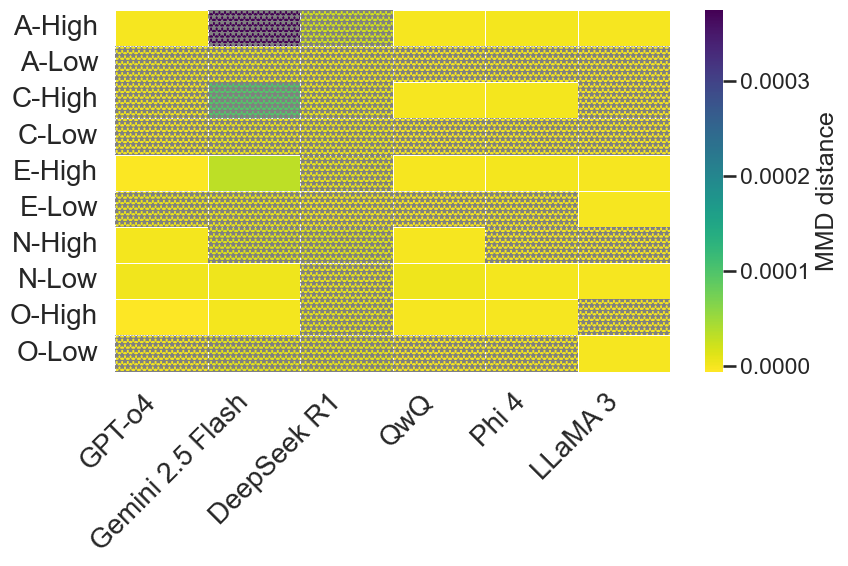

In [213]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# model_results: dict[model_name -> df]
model_names = list(model_results.keys())

# Collect all personas across models
all_personas = sorted(
    set().union(*[set(df["persona"].unique()) for df in model_results.values()])
)

# Initialize matrices
MMD_df = pd.DataFrame(index=all_personas, columns=model_names, dtype=float)
pval_df = pd.DataFrame(index=all_personas, columns=model_names, dtype=float)

# Fill matrices
for model_name, df in model_results.items():
    for _, row in df.iterrows():
        persona = row["persona"]
        if persona in MMD_df.index:
            MMD_df.loc[persona, model_name] = float(row["MMD"])
            pval_df.loc[persona, model_name] = float(row["p_value"])

sns.set(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(1.5 * len(model_names), 0.6 * len(all_personas)))

# Set global color scale based on observed MMDs
vmin = np.nanmin(MMD_df.values)
vmax = np.nanmax(MMD_df.values)

# Base heatmap (MMD values)
hm = sns.heatmap(
    MMD_df,
    ax=ax,
    cmap="viridis_r",
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "MMD distance"},
    annot=False,
    fmt=".3f",
    annot_kws={"size": 12}
)

# ax.set_xlabel("Model")
# ax.set_ylabel("Persona")
# ax.set_title("Distributional Shift (MMD) by Persona and Model")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)

# Add hatching where p-value < 0.05
n_rows, n_cols = MMD_df.shape
for i in range(n_rows):       # rows = personas
    for j in range(n_cols):   # cols = models
        p = pval_df.iat[i, j]
        if not np.isnan(p) and p < 0.05:
            # Rectangle coordinates: (x=j, y=i), width=1, height=1
            rect = patches.Rectangle(
                (j, i),
                1, 1,
                fill=False,
                hatch="***",
                edgecolor="grey",
                linewidth=0.0  # no extra border, just hatch
            )
            ax.add_patch(rect)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/analysis/results_new/personality_effect_overal.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [214]:
# calculate Wasserstein Distance
def L2square(supp1, supp2):
    """
    Compute pairwise squared Euclidean distances.
    supp1: (dim, n1), supp2: (dim, n2)
    Returns: (n1, n2) distance matrix
    """
    supp1 = supp1.T  # shape (n1, dim)
    supp2 = supp2.T  # shape (n2, dim)
    
    d1_sq = np.sum(supp1**2, axis=1, keepdims=True)  # (n1, 1)
    d2_sq = np.sum(supp2**2, axis=1, keepdims=True).T  # (1, n2)
    pairwise_sq_dist = d1_sq + d2_sq - 2 * np.dot(supp1, supp2.T)
    return pairwise_sq_dist

def ot_distance(cost, p1, p2):
    """
    Solve the OT problem with cost matrix.
    cost: (n1, n2), p1: (n1,), p2: (n2,)
    Returns: total cost and transport plan (gammaij)
    """
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    
    gammaij = ot.emd(p1, p2, cost)
    objval = np.sum(gammaij * cost)
    return objval, gammaij

def DiscreteWasserstein(supp1, supp2, w1, w2):
    """
    Compute squared Wasserstein distance between two discrete distributions.

    Parameters:
    - supp1: ndarray (dim, n1)
    - supp2: ndarray (dim, n2)
    - w1: ndarray (n1,) probabilities for supp1
    - w2: ndarray (n2,) probabilities for supp2

    Returns:
    - dist: float, squared Wasserstein distance
    - gammaij: ndarray (n1, n2), optimal transport plan
    """
    pairdist = L2square(supp1, supp2)
    dist, gammaij = ot_distance(pairdist, w1, w2)
    return dist, gammaij


def get_discrete_wasserstein(X_1, X_2):
    supp1 = X_1.T
    supp2 = X_2.T

    w1 = np.ones(supp1.shape[1]) / supp1.shape[1]
    w2 = np.ones(supp2.shape[1]) / supp2.shape[1]

    dist_sq, _ = DiscreteWasserstein(supp1, supp2, w1, w2)
            
    return np.sqrt(dist_sq)

def compute_wasserstein_vs_vanilla(persona_dfs, persona_names=["Vanilla", "A-High", "A-Low", "C-High", "C-Low", "E-High", "E-Low", "N-High", "N-Low", "O-High", "O-Low"]):
    """
    Compute Wasserstein between vanilla persona (first df)
    and all other personas, using full appraisal distributions.
    
    persona_dfs: list of pandas DataFrames
                 [vanilla_df, persona_a_df, persona_b_df, ...]
    persona_names: list of names, same length as persona_dfs.
                   If None, names are auto-generated.
    num_perm: number of permutations for the MMD test
    gamma: RBF kernel parameter used in mmd_test
    """
    if persona_names is None:
        persona_names = [f"persona_{i}" for i in range(len(persona_dfs))]
    
    # Assume all dfs share the same columns
    all_cols = persona_dfs[0].columns
    appraisal_dims = [c for c in all_cols if c.lower() != "emotion_label"]  # drop label col
    
    # Vanilla = first persona
    vanilla_df = persona_dfs[0]
    X_vanilla = vanilla_df[appraisal_dims].to_numpy(dtype=float)
    
    rows = []
    for idx, (name, df) in enumerate(zip(persona_names, persona_dfs)):
        if idx == 0:
            # skip vanilla vs vanilla
            continue
        
        X_persona = df[appraisal_dims].to_numpy().astype(np.float64)
        
        # Optionally handle empty dfs:
        if X_vanilla.shape[0] == 0 or X_persona.shape[0] == 0:
            dist = np.nan
        else:
            dist = get_discrete_wasserstein(X_vanilla, X_persona)
        
        rows.append({
            "baseline": persona_names[0],
            "persona": name,
            "wasserstein_distance": dist,
            "n_vanilla": X_vanilla.shape[0],
            "n_persona": X_persona.shape[0],
        })
    
    return pd.DataFrame(rows)

In [215]:
compute_wasserstein_vs_vanilla([gpt_vanilla_df, gpt_ahigh_df, gpt_alow_df, gpt_chigh_df, gpt_clow_df, gpt_ehigh_df, gpt_elow_df, gpt_nhigh_df, gpt_nlow_df, gpt_ohigh_df, gpt_olow_df])

,baseline,persona,wasserstein_distance,n_vanilla,n_persona
0,Vanilla,A-High,6.902607,274,274
1,Vanilla,A-Low,11.094649,274,274
2,Vanilla,C-High,7.919071,274,274
3,Vanilla,C-Low,12.709270,274,274
4,Vanilla,E-High,7.333803,274,274
5,Vanilla,E-Low,7.937024,274,274
6,Vanilla,N-High,8.084860,274,274
7,Vanilla,N-Low,9.158579,274,274
8,Vanilla,O-High,6.305773,274,274
9,Vanilla,O-Low,12.468940,274,274


In [216]:
compute_wasserstein_vs_vanilla([gemini_vanilla_df, gemini_ahigh_df, gemini_alow_df, gemini_chigh_df, gemini_clow_df, gemini_ehigh_df, gemini_elow_df, gemini_nhigh_df, gemini_nlow_df, gemini_ohigh_df, gemini_olow_df])


,baseline,persona,wasserstein_distance,n_vanilla,n_persona
0,Vanilla,A-High,9.198342,274,274
1,Vanilla,A-Low,14.125997,274,274
2,Vanilla,C-High,9.614086,274,274
3,Vanilla,C-Low,16.885185,274,274
4,Vanilla,E-High,10.242498,274,274
5,Vanilla,E-Low,9.624899,274,274
6,Vanilla,N-High,14.746273,274,274
7,Vanilla,N-Low,13.130035,274,274
8,Vanilla,O-High,8.830521,274,274
9,Vanilla,O-Low,16.625875,274,274


In [217]:
compute_wasserstein_vs_vanilla([phi_vanilla_df, phi_ahigh_df, phi_alow_df, phi_chigh_df, phi_clow_df, phi_ehigh_df, phi_elow_df, phi_nhigh_df, phi_nlow_df, phi_ohigh_df, phi_olow_df])

,baseline,persona,wasserstein_distance,n_vanilla,n_persona
0,Vanilla,A-High,6.271823,274,274
1,Vanilla,A-Low,15.096768,274,274
2,Vanilla,C-High,6.256967,274,274
3,Vanilla,C-Low,10.856227,274,274
4,Vanilla,E-High,6.247335,274,274
5,Vanilla,E-Low,7.043919,274,274
6,Vanilla,N-High,8.077408,274,274
7,Vanilla,N-Low,8.510406,274,274
8,Vanilla,O-High,5.590986,274,274
9,Vanilla,O-Low,11.530505,274,274


In [218]:
compute_wasserstein_vs_vanilla([llama_vanilla_df, llama_ahigh_df, llama_alow_df, llama_chigh_df, llama_clow_df, llama_ehigh_df, llama_elow_df, llama_nhigh_df, llama_nlow_df, llama_ohigh_df, llama_olow_df])

,baseline,persona,wasserstein_distance,n_vanilla,n_persona
0,Vanilla,A-High,10.027699,274,274
1,Vanilla,A-Low,11.319030,274,274
2,Vanilla,C-High,10.587832,274,274
3,Vanilla,C-Low,9.828456,274,274
4,Vanilla,E-High,10.522655,274,274
5,Vanilla,E-Low,10.244279,274,274
6,Vanilla,N-High,10.249978,274,274
7,Vanilla,N-Low,10.841425,274,274
8,Vanilla,O-High,11.407355,274,274
9,Vanilla,O-Low,10.570410,274,274


In [219]:
compute_wasserstein_vs_vanilla([ds_vanilla_df, ds_ahigh_df, ds_alow_df, ds_chigh_df, ds_clow_df, ds_ehigh_df, ds_elow_df, ds_nhigh_df, ds_nlow_df, ds_ohigh_df, ds_olow_df])

,baseline,persona,wasserstein_distance,n_vanilla,n_persona
0,Vanilla,A-High,8.709002,274,274
1,Vanilla,A-Low,13.496147,274,274
2,Vanilla,C-High,8.060220,274,274
3,Vanilla,C-Low,14.611389,274,274
4,Vanilla,E-High,7.874240,274,274
5,Vanilla,E-Low,9.162762,274,274
6,Vanilla,N-High,15.775223,274,274
7,Vanilla,N-Low,11.185888,274,274
8,Vanilla,O-High,10.257097,274,274
9,Vanilla,O-Low,16.357993,274,274


#### Comparison of each Emotion and each Cognitive Dimension

In [220]:
# what does it mean for the distributions to change statistically? 
# what changes in terms of the appraisals or emotions?
# do they go up or do they go down? 
# why does this change happen? 
# why does it matter? 

In [221]:
emotion_list = ["happiness", "surprise", "hope", "interest", "pride", "boredom", "disgust", "shame", "guilt", "sadness", "fear", "anger", "frustration", "contempt", "challenge"]

# pick up the distribution for each emotion, and compare with it
def get_emotion_specific_comparison(original_persona_dfs, model_name):
    print(f"Current comparison for Model: {model_name}")
    for emotion in emotion_list: 
        print(f"Emotion: {emotion}")
        modified_persona_dfs = []
        for original_df in original_persona_dfs: 
            curr_emotion_df = original_df[original_df["emotion_label"] == emotion]
            modified_persona_dfs.append(curr_emotion_df)
        # print(modified_persona_dfs)
        
        print(f"MMD: {compute_mmd_vs_vanilla(modified_persona_dfs)}")
        print(f"Wasserstein Distances: {compute_wasserstein_vs_vanilla(modified_persona_dfs)}")

In [222]:
persona_dfs_gpt = [gpt_vanilla_df, gpt_ahigh_df, gpt_alow_df, gpt_chigh_df, gpt_clow_df, gpt_ehigh_df, gpt_elow_df, gpt_nhigh_df, gpt_nlow_df, gpt_ohigh_df, gpt_olow_df]
get_emotion_specific_comparison(persona_dfs_gpt, "GPT")

Current comparison for Model: GPT
Emotion: happiness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.000038   0.1820         14         14
1  Vanilla   A-Low  0.000580   0.0310         14         14
2  Vanilla  C-High -0.000041   0.5920         14         14
3  Vanilla   C-Low  0.000102   0.0005         14         14
4  Vanilla  E-High  0.000707   0.1350         14         14
5  Vanilla   E-Low  0.000020   0.4235         14         14
6  Vanilla  N-High  0.000027   0.1125         14         14
7  Vanilla   N-Low  0.000823   0.0120         14         14
8  Vanilla  O-High -0.000810   0.9410         14         14
9  Vanilla   O-Low  0.000027   0.0000         14         14
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              5.063878         14         14
1  Vanilla   A-Low              9.801603         14         14
2  Vanilla  C-High              6.100351         14         14
3  Vani

In [223]:
persona_dfs_gemini = [gemini_vanilla_df, gemini_ahigh_df, gemini_alow_df, gemini_chigh_df, gemini_clow_df, gemini_ehigh_df, gemini_elow_df, gemini_nhigh_df, gemini_nlow_df, gemini_ohigh_df, gemini_olow_df]
get_emotion_specific_comparison(persona_dfs_gemini, "Gemini")

Current comparison for Model: Gemini
Emotion: happiness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.000262   0.0580         14         14
1  Vanilla   A-Low  0.000269   0.0000         14         14
2  Vanilla  C-High  0.000251   0.1395         14         14
3  Vanilla   C-Low  0.000920   0.0000         14         14
4  Vanilla  E-High -0.002080   0.5010         14         14
5  Vanilla   E-Low  0.000082   0.2420         14         14
6  Vanilla  N-High  0.000269   0.0000         14         14
7  Vanilla   N-Low  0.000119   0.2405         14         14
8  Vanilla  O-High  0.000318   0.1885         14         14
9  Vanilla   O-Low  0.000269   0.0015         14         14
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              9.651055         14         14
1  Vanilla   A-Low             18.183588         14         14
2  Vanilla  C-High              8.485281         14         14
3  V

In [224]:
persona_dfs_phi = [phi_vanilla_df, phi_ahigh_df, phi_alow_df, phi_chigh_df, phi_clow_df, phi_ehigh_df, phi_elow_df, phi_nhigh_df, phi_nlow_df, phi_ohigh_df, phi_olow_df]
get_emotion_specific_comparison(persona_dfs_phi, "Phi")

Current comparison for Model: Phi
Emotion: happiness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High -0.000248   0.5685         14         14
1  Vanilla   A-Low  0.000211   0.0005         14         14
2  Vanilla  C-High  0.000201   0.2750         14         14
3  Vanilla   C-Low  0.000211   0.0000         14         14
4  Vanilla  E-High  0.000554   0.2995         14         14
5  Vanilla   E-Low  0.000211   0.0870         14         14
6  Vanilla  N-High  0.000211   0.0035         14         14
7  Vanilla   N-Low  0.000156   0.2260         14         14
8  Vanilla  O-High  0.000176   0.3840         14         14
9  Vanilla   O-Low  0.000211   0.0005         14         14
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              4.992852         14         14
1  Vanilla   A-Low             19.932027         14         14
2  Vanilla  C-High              4.675162         14         14
3  Vani

In [225]:
persona_dfs_llama = [llama_vanilla_df, llama_ahigh_df, llama_alow_df, llama_chigh_df, llama_clow_df, llama_ehigh_df, llama_elow_df, llama_nhigh_df, llama_nlow_df, llama_ohigh_df, llama_olow_df]
get_emotion_specific_comparison(persona_dfs_llama, "LLama")

Current comparison for Model: LLama
Emotion: happiness
MMD:   baseline persona           MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  1.706475e-14   0.4640         14         14
1  Vanilla   A-Low  2.065259e-14   0.0030         14         14
2  Vanilla  C-High  2.966955e-16   0.4795         14         14
3  Vanilla   C-Low  2.070138e-14   0.0410         14         14
4  Vanilla  E-High  6.160656e-11   0.0905         14         14
5  Vanilla   E-Low  2.265176e-11   0.1850         14         14
6  Vanilla  N-High  2.079898e-14   0.0225         14         14
7  Vanilla   N-Low -4.223808e-10   0.5700         14         14
8  Vanilla  O-High  2.065259e-14   0.0775         14         14
9  Vanilla   O-Low  2.065259e-14   0.0020         14         14
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              9.331207         14         14
1  Vanilla   A-Low             11.988089         14         14
2  Vanilla  C-High      

In [226]:
persona_dfs_ds = [ds_vanilla_df, ds_ahigh_df, ds_alow_df, ds_chigh_df, ds_clow_df, ds_ehigh_df, ds_elow_df, ds_nhigh_df, ds_nlow_df, ds_ohigh_df, ds_olow_df]
get_emotion_specific_comparison(persona_dfs_ds, "DeepSeek")

Current comparison for Model: DeepSeek
Emotion: happiness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.000205   0.0230         14         14
1  Vanilla   A-Low  0.000203   0.0105         14         14
2  Vanilla  C-High  0.000185   0.3050         14         14
3  Vanilla   C-Low  0.000203   0.0000         14         14
4  Vanilla  E-High  0.000951   0.0660         14         14
5  Vanilla   E-Low  0.000203   0.0000         14         14
6  Vanilla  N-High  0.000203   0.0000         14         14
7  Vanilla   N-Low -0.000039   0.5455         14         14
8  Vanilla  O-High  0.000416   0.0155         14         14
9  Vanilla   O-Low  0.000203   0.0000         14         14
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              8.093207         14         14
1  Vanilla   A-Low             14.429632         14         14
2  Vanilla  C-High              6.244998         14         14
3 

In [227]:
# compare emotion-specific distributions for direction of change
emotion_list = ["happiness", "surprise", "hope", "interest", "pride", "boredom", "disgust", "shame", "guilt", "sadness", "fear", "anger", "frustration", "contempt", "challenge"]
persona_list = ["A-High", "A-Low", "C-High", "C-Low", "E-High", "E-Low", "N-High", "N-Low", "O-High", "O-Low"]
emotion_specific_mmd = {k: {} for k in emotion_list}
emotion_specific_change = {k: {} for k in emotion_list}
persona_df_models = {
    "GPT-o4": persona_dfs_gpt,
    "Gemini 2.5 Flash": persona_dfs_gemini, 
    "DeepSeek R1": persona_dfs_ds,
    "QwQ": persona_dfs_qwq,
    "Phi 4": persona_dfs_phi, 
    "LLaMA 3": persona_dfs_llama
}

# pick up the distribution for each emotion, and compare with it
def get_emotion_specific_mmds(original_persona_dfs, model_name):
    print(f"Current comparison for Model: {model_name}")
    for emotion in emotion_list: 
        print(f"Emotion: {emotion}")
        modified_persona_dfs = []
        for original_df in original_persona_dfs: 
            curr_emotion_df = original_df[original_df["emotion_label"] == emotion]
            modified_persona_dfs.append(curr_emotion_df)
        # print(modified_persona_dfs)
        
        emotion_specific_mmd[emotion] = compute_mmd_vs_vanilla(modified_persona_dfs)
    return emotion_specific_mmd

def across_model_emotion_specific_comparison():
    # iterate over all models 
    for model, persona_dfs in persona_df_models.items(): 
        # pick all the rows pertaining to each persona
        emotion_specific_mmds = get_emotion_specific_mmds(persona_dfs, model)
        for emotion, mmd_df in emotion_specific_mmds.items(): 
            # we have the model, we have the emotion 
            for persona in persona_list: 
                persona_p_val = mmd_df[mmd_df["persona"] == persona]["p_value"].values[0].item()
                append_val = (persona_p_val < 0.05)
                if persona in emotion_specific_change[emotion]: 
                    emotion_specific_change[emotion][persona].append(append_val)
                else: 
                    emotion_specific_change[emotion][persona] = [append_val]
    
    # average everything out
    for emotion, emotion_items in emotion_specific_change.items(): 
        for persona, sig_values in emotion_items.items(): 
            emotion_specific_change[emotion][persona] = sum(sig_values)

    return emotion_specific_change
        

In [266]:
emotion_specific_change = across_model_emotion_specific_comparison()

Current comparison for Model: GPT-o4
Emotion: happiness
Emotion: surprise
Emotion: hope
Emotion: interest
Emotion: pride
Emotion: boredom
Emotion: disgust
Emotion: shame
Emotion: guilt
Emotion: sadness
Emotion: fear
Emotion: anger
Emotion: frustration
Emotion: contempt
Emotion: challenge
Current comparison for Model: Gemini 2.5 Flash
Emotion: happiness
Emotion: surprise
Emotion: hope
Emotion: interest
Emotion: pride
Emotion: boredom
Emotion: disgust
Emotion: shame
Emotion: guilt
Emotion: sadness
Emotion: fear
Emotion: anger
Emotion: frustration
Emotion: contempt
Emotion: challenge
Current comparison for Model: DeepSeek R1
Emotion: happiness
Emotion: surprise
Emotion: hope
Emotion: interest
Emotion: pride
Emotion: boredom
Emotion: disgust
Emotion: shame
Emotion: guilt
Emotion: sadness
Emotion: fear
Emotion: anger
Emotion: frustration
Emotion: contempt
Emotion: challenge
Current comparison for Model: QwQ
Emotion: happiness
Emotion: surprise
Emotion: hope
Emotion: interest
Emotion: pride


In [267]:
print(emotion_specific_change)
sig_counts = emotion_specific_change

{'happiness': {'A-High': 1, 'A-Low': 5, 'C-High': 0, 'C-Low': 6, 'E-High': 0, 'E-Low': 2, 'N-High': 5, 'N-Low': 1, 'O-High': 1, 'O-Low': 6}, 'surprise': {'A-High': 0, 'A-Low': 5, 'C-High': 3, 'C-Low': 5, 'E-High': 0, 'E-Low': 2, 'N-High': 6, 'N-Low': 2, 'O-High': 0, 'O-Low': 5}, 'hope': {'A-High': 0, 'A-Low': 5, 'C-High': 0, 'C-Low': 4, 'E-High': 1, 'E-Low': 1, 'N-High': 3, 'N-Low': 3, 'O-High': 1, 'O-Low': 6}, 'interest': {'A-High': 0, 'A-Low': 5, 'C-High': 1, 'C-Low': 6, 'E-High': 2, 'E-Low': 1, 'N-High': 5, 'N-Low': 5, 'O-High': 1, 'O-Low': 5}, 'pride': {'A-High': 3, 'A-Low': 3, 'C-High': 0, 'C-Low': 5, 'E-High': 1, 'E-Low': 2, 'N-High': 4, 'N-Low': 2, 'O-High': 1, 'O-Low': 5}, 'boredom': {'A-High': 3, 'A-Low': 4, 'C-High': 2, 'C-Low': 3, 'E-High': 0, 'E-Low': 1, 'N-High': 3, 'N-Low': 5, 'O-High': 1, 'O-Low': 1}, 'disgust': {'A-High': 2, 'A-Low': 4, 'C-High': 1, 'C-Low': 5, 'E-High': 1, 'E-Low': 1, 'N-High': 1, 'N-Low': 3, 'O-High': 1, 'O-Low': 5}, 'shame': {'A-High': 3, 'A-Low': 6,

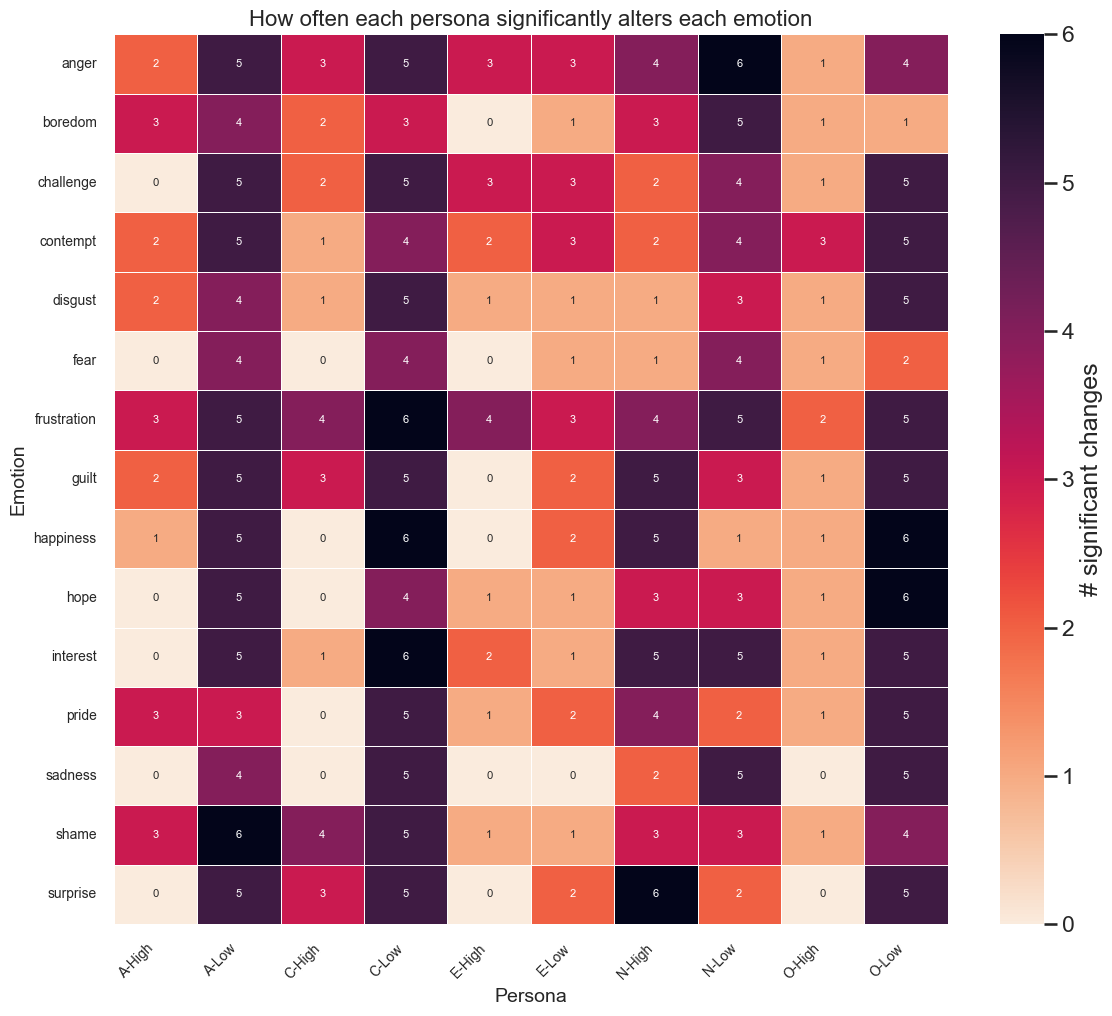

In [268]:
# Make DataFrame: rows = emotions, cols = personas
sig_df = pd.DataFrame.from_dict(sig_counts, orient="index")

# Replace missing entries with 0 and ensure integer dtype
sig_df = sig_df.fillna(0).astype(int)

# Optional: sort emotions and personas
sig_df = sig_df.sort_index(axis=0)       # sort rows (emotions)
sig_df = sig_df.reindex(sorted(sig_df.columns), axis=1)  # sort columns (personas)

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(1.2 * sig_df.shape[1], 0.7 * sig_df.shape[0]))

ax = sns.heatmap(
    sig_df,
    cmap="rocket_r",          # or "mako", "viridis"
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="d",
    annot_kws={"size": 8},
    cbar_kws={"label": "# significant changes"}
)

ax.set_xlabel("Persona", fontsize=14)
ax.set_ylabel("Emotion", fontsize=14)
ax.set_title("How often each persona significantly alters each emotion", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


In [284]:
# pick up the distribution for each emotion, and compare with it
def get_appraisal_specific_comparison(original_persona_dfs, model_name):
    print(f"Current comparison for Model: {model_name}")
    appraisal_specific_mmds = {}
    for appraisal in appraisal_columns: 
        print(f"Appraisal: {appraisal}")
        modified_persona_dfs = []
        for original_df in original_persona_dfs: 
            curr_emotion_df = pd.DataFrame(original_df[appraisal])
            modified_persona_dfs.append(curr_emotion_df)
        # print(modified_persona_dfs)
        appraisal_specific_mmds[appraisal] = compute_mmd_vs_vanilla(modified_persona_dfs)
        
        print(f"MMD: {appraisal_specific_mmds[appraisal]}")
        # print(f"Wasserstein Distances: {compute_wasserstein_vs_vanilla(modified_persona_dfs)}")
    return appraisal_specific_mmds

In [231]:
get_appraisal_specific_comparison(persona_dfs_gpt, "GPT")

Current comparison for Model: GPT
Appraisal: pleasantness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.004719   0.0795        274        274
1  Vanilla   A-Low  0.007124   0.0415        274        274
2  Vanilla  C-High  0.002113   0.2110        274        274
3  Vanilla   C-Low  0.001571   0.2315        274        274
4  Vanilla  E-High  0.009243   0.0255        274        274
5  Vanilla   E-Low  0.008450   0.0255        274        274
6  Vanilla  N-High  0.008442   0.0265        274        274
7  Vanilla   N-Low  0.056495   0.0000        274        274
8  Vanilla  O-High  0.002603   0.1840        274        274
9  Vanilla   O-Low  0.058079   0.0000        274        274
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              0.547056        274        274
1  Vanilla   A-Low              0.563488        274        274
2  Vanilla  C-High              0.490791        274        274
3 

In [232]:
get_appraisal_specific_comparison(persona_dfs_gemini, "Gemini")

Current comparison for Model: Gemini
Appraisal: pleasantness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.004390   0.0980        274        274
1  Vanilla   A-Low  0.005025   0.0810        274        274
2  Vanilla  C-High  0.002525   0.1710        274        274
3  Vanilla   C-Low  0.010373   0.0185        274        274
4  Vanilla  E-High  0.024319   0.0010        274        274
5  Vanilla   E-Low  0.007780   0.0365        274        274
6  Vanilla  N-High  0.096796   0.0000        274        274
7  Vanilla   N-Low  0.189307   0.0000        274        274
8  Vanilla  O-High  0.018737   0.0050        274        274
9  Vanilla   O-Low  0.053120   0.0000        274        274
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              0.992674        274        274
1  Vanilla   A-Low              0.854358        274        274
2  Vanilla  C-High              0.494495        274        274

In [233]:
get_appraisal_specific_comparison(persona_dfs_phi, "Phi")

Current comparison for Model: Phi
Appraisal: pleasantness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.007292   0.0470        274        274
1  Vanilla   A-Low  0.135798   0.0000        274        274
2  Vanilla  C-High -0.000886   0.5120        274        274
3  Vanilla   C-Low  0.022558   0.0000        274        274
4  Vanilla  E-High  0.020643   0.0015        274        274
5  Vanilla   E-Low  0.018798   0.0015        274        274
6  Vanilla  N-High  0.055019   0.0000        274        274
7  Vanilla   N-Low  0.085160   0.0000        274        274
8  Vanilla  O-High  0.000121   0.3650        274        274
9  Vanilla   O-Low  0.054570   0.0000        274        274
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              0.498172        274        274
1  Vanilla   A-Low              1.924676        274        274
2  Vanilla  C-High              0.422885        274        274
3 

In [234]:
get_appraisal_specific_comparison(persona_dfs_llama, "LLama")

Current comparison for Model: LLama
Appraisal: pleasantness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.039102    0.000        274        274
1  Vanilla   A-Low  0.085261    0.000        274        274
2  Vanilla  C-High  0.022072    0.001        274        274
3  Vanilla   C-Low  0.039742    0.000        274        274
4  Vanilla  E-High  0.047117    0.000        274        274
5  Vanilla   E-Low  0.040086    0.000        274        274
6  Vanilla  N-High  0.024409    0.001        274        274
7  Vanilla   N-Low  0.141478    0.000        274        274
8  Vanilla  O-High  0.006859    0.062        274        274
9  Vanilla   O-Low  0.055294    0.000        274        274
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              2.150369        274        274
1  Vanilla   A-Low              2.125617        274        274
2  Vanilla  C-High              1.912311        274        274


In [235]:
get_appraisal_specific_comparison(persona_dfs_ds, "DeepSeek")

Current comparison for Model: DeepSeek
Appraisal: pleasantness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.005012   0.0975        274        274
1  Vanilla   A-Low  0.049239   0.0000        274        274
2  Vanilla  C-High -0.002288   0.7135        274        274
3  Vanilla   C-Low  0.021904   0.0005        274        274
4  Vanilla  E-High  0.022100   0.0020        274        274
5  Vanilla   E-Low  0.015420   0.0030        274        274
6  Vanilla  N-High  0.251382   0.0000        274        274
7  Vanilla   N-Low  0.098961   0.0000        274        274
8  Vanilla  O-High  0.118110   0.0000        274        274
9  Vanilla   O-Low  0.135139   0.0000        274        274
Wasserstein Distances:   baseline persona  wasserstein_distance  n_vanilla  n_persona
0  Vanilla  A-High              0.573121        274        274
1  Vanilla   A-Low              0.908195        274        274
2  Vanilla  C-High              0.501821        274        2

In [46]:
from scipy.stats import mannwhitneyu, rankdata, wasserstein_distance
def mann_whitney_test(list_a, list_b, alternative="two-sided"):
    """
    Returns: U, p, A, W1
      - U: Mann-Whitney U statistic for x vs y
      - p: p-value with the specified alternative
      - A: Probability of superiority P(X>Y) + 0.5*P(X=Y)  (independent of 'alternative')
      - W1: Wasserstein-1 distance (in rating units) computed on raw samples

    alternative ∈ {"two-sided", "greater", "less"}
    """
    x = np.asarray(list_a, float)
    y = np.asarray(list_b, float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, np.nan, np.nan

    # --- U for x vs y (from ranks, handles ties correctly & avoids two-sided min(Ux,Uy) ambiguity) ---
    combined = np.concatenate([x, y])
    ranks = rankdata(combined, method="average")
    R_x = ranks[:n1].sum()
    Ux = R_x - n1 * (n1 + 1) / 2.0          # #wins of x over y + 0.5 * ties
    Uy = n1 * n2 - Ux
    U_for_report = Ux  # by convention, "U for x"

    # p-value from scipy (uses exact/normal approx as appropriate)
    # SciPy's statistic equals Ux for one-sided; for two-sided it may be min(Ux,Uy),
    # but we only use it for the p-value. We report Ux above.
    _, p = mannwhitneyu(x, y, alternative=alternative)

    # Probability of superiority (AUC / Vargha–Delaney A)
    # A = Ux / (n1 * n2)

    # Wasserstein-1 distance on raw samples (interpretable in rating units)
    # W1 = wasserstein_distance(x, y)

    return float(U_for_report), float(p)

In [ ]:
from collections import defaultdict

# compare appraisal-specific distributions for direction of change
emotion_list = ["happiness", "surprise", "hope", "interest", "pride", "boredom", "disgust", "shame", "guilt", "sadness", "fear", "anger", "frustration", "contempt", "challenge"]
persona_list = ["A-High", "A-Low", "C-High", "C-Low", "E-High", "E-Low", "N-High", "N-Low", "O-High", "O-Low"]
emotion_specific_mmd = {k: {} for k in emotion_list}
emotion_specific_change = {k: {} for k in emotion_list}
persona_df_models = {
    "GPT-o4": persona_dfs_gpt,
    "Gemini 2.5 Flash": persona_dfs_gemini, 
    "DeepSeek R1": persona_dfs_ds,
    "QwQ": persona_dfs_qwq,
    "Phi 4": persona_dfs_phi, 
    "LLaMA 3": persona_dfs_llama
}

def across_model_appraisal_change():
    across_model_appraisal_change = {k: {} for k in appraisal_columns}
    
    for model, persona_dfs in persona_df_models.items(): 
        appraisal_specific_mmds = get_appraisal_specific_comparison(persona_dfs, model)
        
        for appraisal, mmd_df in appraisal_specific_mmds.items(): 
            for persona in persona_list: 
                persona_p_val = mmd_df[mmd_df["persona"] == persona]["p_value"].values[0].item()
                append_val = (persona_p_val < 0.05)
                
                if persona in across_model_appraisal_change[appraisal]: 
                    across_model_appraisal_change[appraisal][persona].append(append_val)
                else: 
                    across_model_appraisal_change[appraisal][persona] = [append_val]
    
    # average everything out
    for appraisal, appraisal_items in across_model_appraisal_change.items(): 
        for persona, sig_values in appraisal_items.items(): 
            across_model_appraisal_change[appraisal][persona] = sum(sig_values)

    return across_model_appraisal_change

# pick up the distribution for each emotion, and compare with it
def get_appraisal_specific_df(original_persona_dfs, model_name):
    print(f"Current comparison for Model: {model_name}")
    appraisal_mmd_dfs = {k: {} for k in appraisal_columns}
    for appraisal in appraisal_columns: 
        print(f"Appraisal: {appraisal}")
        modified_persona_dfs = []
        for original_df in original_persona_dfs: 
            curr_appraisal_df = original_df[appraisal].to_numpy()
            modified_persona_dfs.append(curr_appraisal_df)
        
        appraisal_mmd_dfs[appraisal] = modified_persona_dfs
    
    return appraisal_mmd_dfs

def compare_mann_whitney(appraisal, appraisal_ratings): 
    appraisal_change_persona = defaultdict(int)

    vanilla_rating = appraisal_ratings[0]
    appraisal_ratings = appraisal_ratings[1:]
    
    for appraisal_rating, persona in zip(appraisal_ratings, persona_list): 
        _, greater_p = mann_whitney_test(appraisal_rating, vanilla_rating, "greater")  # appraisal with persona greater than vanilla 
        _, lesser_p = mann_whitney_test(appraisal_rating, vanilla_rating, "less")

        if greater_p < 0.05: 
            # no difference
            appraisal_change_persona[(appraisal, persona)] = appraisal_change_persona.get((appraisal, persona), 0) + 1
        elif lesser_p < 0.05:  
            appraisal_change_persona[(appraisal, persona)] = appraisal_change_persona.get((appraisal, persona), 0) - 1
        else: 
            appraisal_change_persona[(appraisal, persona)] = appraisal_change_persona.get((appraisal, persona), 0) + 0
    
    return appraisal_change_persona

def across_model_appraisal_specific_comparison():
    appraisal_change_full = defaultdict(int)
    appraisal_change_model_specific = {}
    
    for model, persona_dfs in persona_df_models.items(): 
        appraisal_specific_dfs = get_appraisal_specific_df(persona_dfs, model) # stores appraisal -> list of ratings for each persona
        for appraisal, rating_list in appraisal_specific_dfs.items(): 
            curr_change = compare_mann_whitney(appraisal, rating_list) # this has (appraisal, persona) -> value 

            for tup, value in curr_change.items(): 
                appraisal_change_full[tup] = appraisal_change_full.get(tup, 0) + value
                if model not in appraisal_change_model_specific: 
                    appraisal_change_model_specific[model] = {tup: value}
                else:
                    appraisal_change_model_specific[model][tup] = value

        
    return appraisal_change_full, appraisal_change_model_specific


NameError: name 'persona_dfs_gpt' is not defined

In [286]:
appraisal_change = across_model_appraisal_change()

Current comparison for Model: GPT-o4
Appraisal: pleasantness
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.004719   0.0875        274        274
1  Vanilla   A-Low  0.007124   0.0320        274        274
2  Vanilla  C-High  0.002113   0.2010        274        274
3  Vanilla   C-Low  0.001571   0.2575        274        274
4  Vanilla  E-High  0.009243   0.0245        274        274
5  Vanilla   E-Low  0.008450   0.0265        274        274
6  Vanilla  N-High  0.008442   0.0210        274        274
7  Vanilla   N-Low  0.056495   0.0000        274        274
8  Vanilla  O-High  0.002603   0.1820        274        274
9  Vanilla   O-Low  0.058079   0.0000        274        274
Appraisal: enjoyment
MMD:   baseline persona       MMD  p_value  n_vanilla  n_persona
0  Vanilla  A-High  0.001088   0.2725        274        274
1  Vanilla   A-Low  0.014400   0.0055        274        274
2  Vanilla  C-High  0.001157   0.2795        274        274
3  Vanil

In [26]:
import json
      
# # Store the dictionary to a JSON file
# with open('appraisal_change_across_models.json', 'w') as f:
#     json.dump(appraisal_change, f, indent=4) # indent for pretty-printing

In [28]:
with open('appraisal_change_across_models.json', 'r') as f:
    appraisal_change = json.load(f)

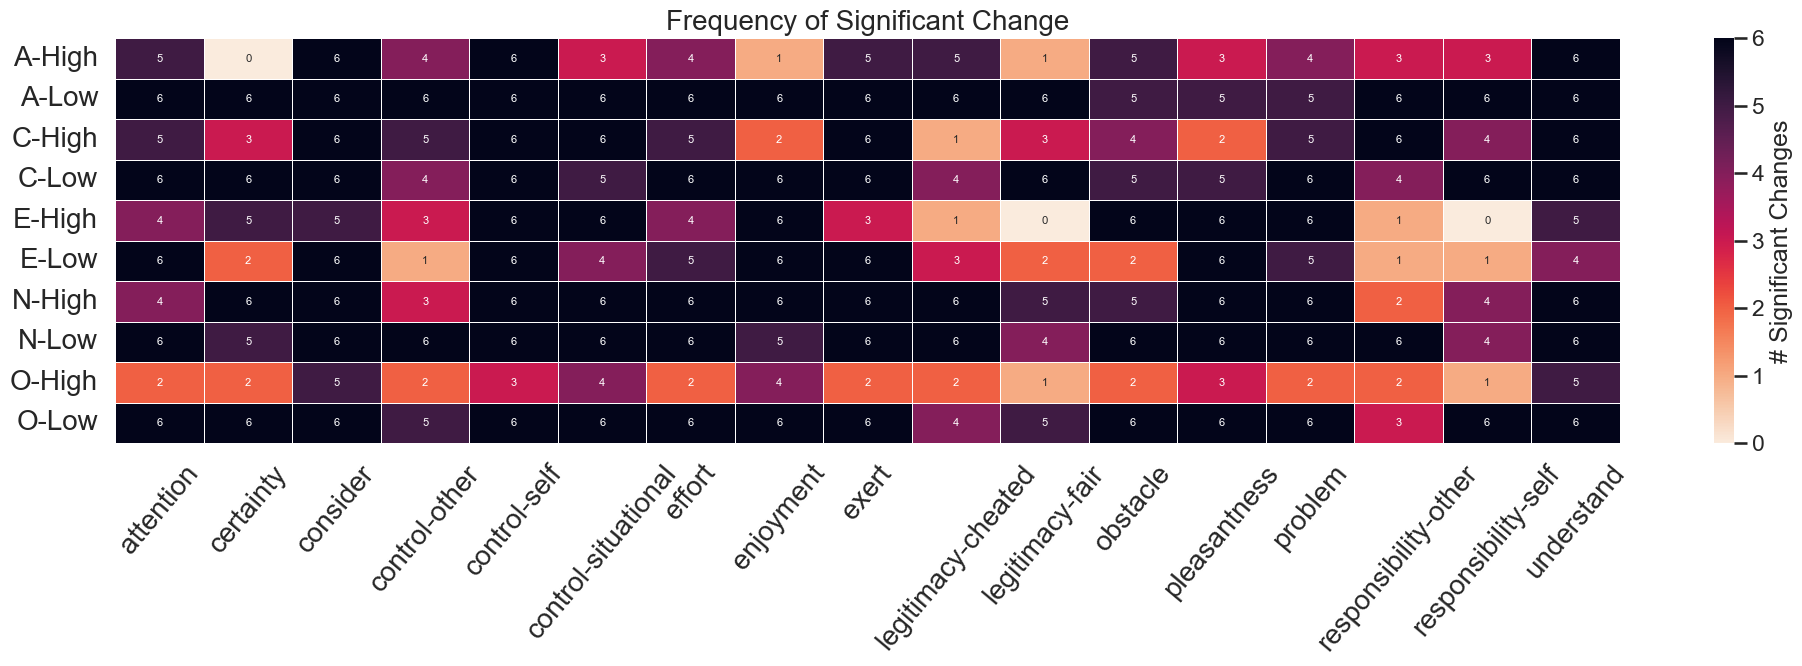

In [33]:
# Make DataFrame: rows = emotions, cols = personas
sig_df = pd.DataFrame.from_dict(appraisal_change, orient="index")

# Replace missing entries with 0 and ensure integer dtype
sig_df = sig_df.fillna(0).astype(int)

# Optional: sort emotions and personas
sig_df = sig_df.sort_index(axis=0)       # sort rows (emotions)
sig_df = sig_df.reindex(sorted(sig_df.columns), axis=1)  # sort columns (personas)

sig_df = sig_df.T

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(1.2 * sig_df.shape[1], 0.7 * sig_df.shape[0]))

ax = sns.heatmap(
    sig_df,
    cmap="rocket_r",          # or "mako", "viridis"
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="d",
    annot_kws={"size": 8},
    cbar_kws={"label": "# Significant Changes"}
)

# ax.set_xlabel("Persona", fontsize=20)
# ax.set_ylabel("Appraisal", fontsize=20)
ax.set_title("Frequency of Significant Change", fontsize=20)

plt.yticks(rotation=0, ha="right", fontsize=20)
plt.xticks(rotation=50, fontsize=20)
plt.tight_layout()
plt.savefig("./frequency_significant_change_appraisal_persona.pdf", format = "pdf", bbox_inches="tight")
plt.show()


In [253]:
effect_dict, model_effect_dict = across_model_appraisal_specific_comparison()

Current comparison for Model: GPT-o4
Appraisal: pleasantness
Appraisal: enjoyment
Appraisal: consider
Appraisal: attention
Appraisal: understand
Appraisal: control-situational
Appraisal: control-self
Appraisal: control-other
Appraisal: certainty
Appraisal: problem
Appraisal: obstacle
Appraisal: legitimacy-cheated
Appraisal: legitimacy-fair
Appraisal: responsibility-self
Appraisal: responsibility-other
Appraisal: exert
Appraisal: effort
Current comparison for Model: Gemini 2.5 Flash
Appraisal: pleasantness
Appraisal: enjoyment
Appraisal: consider
Appraisal: attention
Appraisal: understand
Appraisal: control-situational
Appraisal: control-self
Appraisal: control-other
Appraisal: certainty
Appraisal: problem
Appraisal: obstacle
Appraisal: legitimacy-cheated
Appraisal: legitimacy-fair
Appraisal: responsibility-self
Appraisal: responsibility-other
Appraisal: exert
Appraisal: effort
Current comparison for Model: DeepSeek R1
Appraisal: pleasantness
Appraisal: enjoyment
Appraisal: consider
App

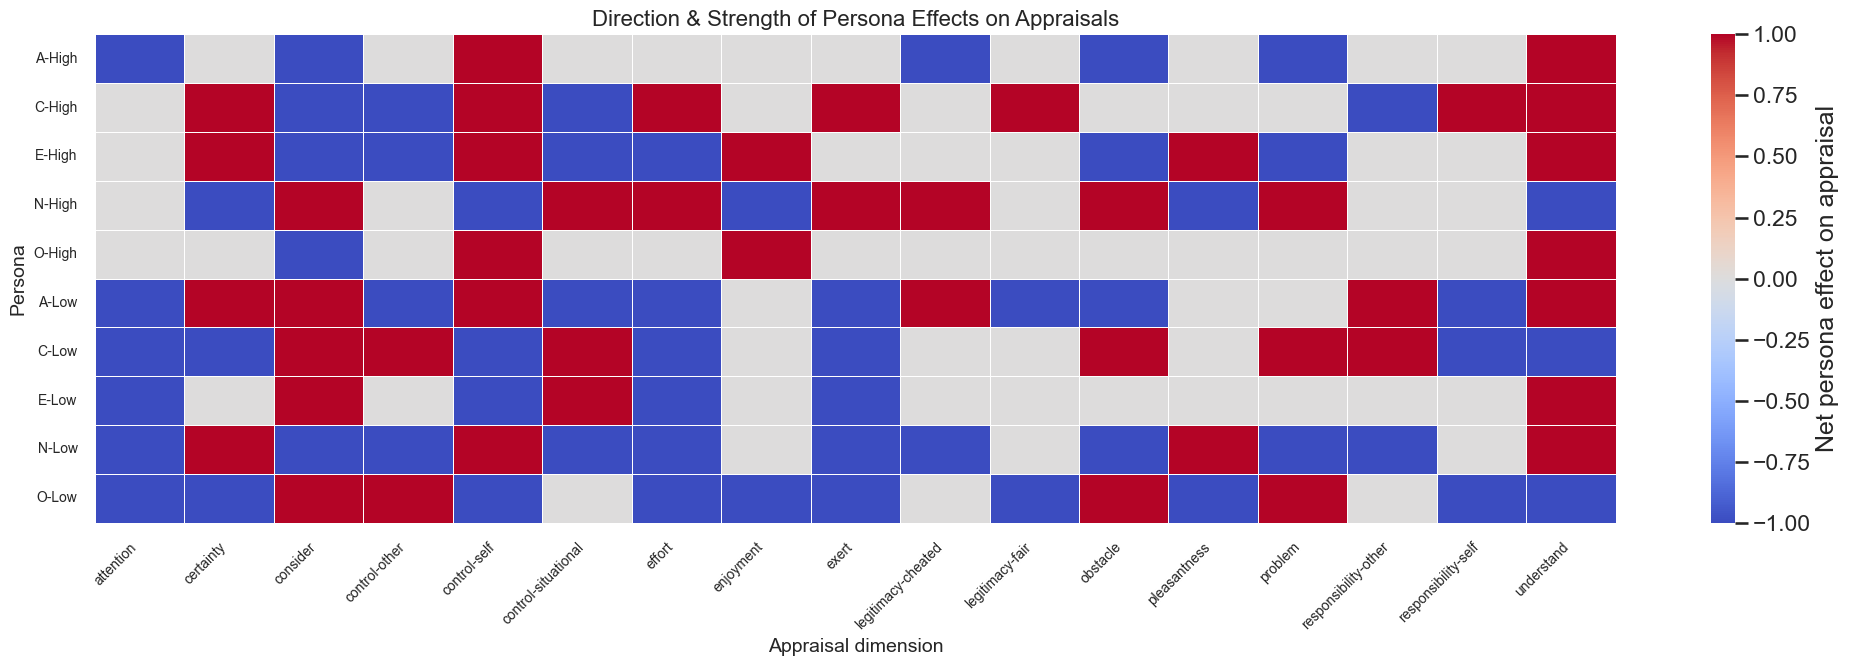

In [257]:
dims = sorted({dim for (dim, persona) in model_effect_dict["GPT-o4"].keys()})
personas = sorted({persona for (dim, persona) in model_effect_dict["GPT-o4"].keys()})

# Create empty DataFrame: rows = personas, cols = dimensions
effect_df = pd.DataFrame(index=personas, columns=dims, dtype=float)

# Fill with values from the dict
for (dim, persona), val in model_effect_dict["GPT-o4"].items():
    effect_df.loc[persona, dim] = val

desired_order = [
    "A-High",
    "C-High",
    "E-High",
    "N-High",
    "O-High",
    "A-Low",
    "C-Low",
    "E-Low",
    "N-Low",
    "O-Low"
]


# Optionally fill missing combos (if any) with 0 or NaN
effect_df = effect_df.fillna(0)
effect_df = effect_df.reindex(desired_order)

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(1.2 * len(dims), 0.7 * len(personas)))

ax = sns.heatmap(
    effect_df,
    cmap="coolwarm",      # or "RdBu_r", "seismic", etc.
    vmin=-1,
    vmax=1,
    center=0,             # ensure 0 is the neutral midpoint
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Net persona effect on appraisal"}
)

ax.set_xlabel("Appraisal dimension", fontsize=14)
ax.set_ylabel("Persona", fontsize=14)
ax.set_title("Direction & Strength of Persona Effects on Appraisals", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [259]:
effect_long = (
    effect_df
    .reset_index()
    .rename(columns={"index": "persona"})  # if index is unnamed
    .melt(id_vars="persona", var_name="dimension", value_name="effect")
)

# Optional: ensure sorted order
effect_long["dimension"] = effect_long["dimension"].astype("category")
effect_long["dimension"] = effect_long["dimension"].cat.reorder_categories(
    sorted(effect_df.columns), ordered=True
)

effect_long["persona"] = effect_long["persona"].astype("category")

In [ ]:
# What are the personalities that lead to most significant changes? 
# What are the appraisals that get changed significantly the most often? 
# For the most impactful persona, how does it affect the different appraisals -- does it increase or decrease the ratings for different appraisals? 
# Does neuroticism lead to more negative appraisals? 

# the impact of "positive personas" should be positive : better coping and/or goal conduciveness
# does this make model "more balanced"? what does it do? 

In [35]:
# compare "positive personas" to see their effect on appraisals 
gpt_positive_personas = [gpt_ahigh_df, gpt_chigh_df, gpt_ehigh_df, gpt_nlow_df, gpt_ohigh_df]
gemini_positive_personas = [gemini_ahigh_df, gemini_chigh_df, gemini_ehigh_df, gemini_nlow_df, gemini_ohigh_df]
llama_positive_personas = [llama_ahigh_df, llama_chigh_df, llama_ehigh_df, llama_nlow_df, llama_ohigh_df]
phi_positive_personas = [phi_ahigh_df, phi_chigh_df, phi_ehigh_df, phi_nlow_df, phi_ohigh_df]
ds_positive_personas = [ds_ahigh_df, ds_chigh_df, ds_ehigh_df, ds_nlow_df, ds_ohigh_df]
qwq_positive_personas = [qwq_ahigh_df, qwq_chigh_df, qwq_ehigh_df, qwq_nlow_df, qwq_ohigh_df]

In [36]:
gpt_negative_personas = [gpt_alow_df, gpt_clow_df, gpt_elow_df, gpt_nhigh_df, gpt_olow_df]
gemini_negative_personas = [gemini_alow_df, gemini_clow_df, gemini_elow_df, gemini_nhigh_df, gemini_olow_df]
llama_negative_personas = [llama_alow_df, llama_clow_df, llama_elow_df, llama_nhigh_df, llama_olow_df]
phi_negative_personas = [phi_alow_df, phi_clow_df, phi_elow_df, phi_nhigh_df, phi_olow_df]
ds_negative_personas = [ds_alow_df, ds_clow_df, ds_elow_df, ds_nhigh_df, ds_olow_df]
qwq_negative_personas = [qwq_alow_df, qwq_clow_df, qwq_elow_df, qwq_nhigh_df, qwq_olow_df]

In [63]:
positive_personas = {
    "GPT o4-mini": gpt_positive_personas, 
    "Gemini 2.5 Flash": gemini_positive_personas, 
    "LLaMA 3": llama_positive_personas, 
    "Phi 4": phi_positive_personas, 
    "DeepSeek R1": ds_positive_personas, 
    "QwQ": qwq_positive_personas
}
negative_personas = {
    "GPT o4-mini": gpt_negative_personas, 
    "Gemini 2.5 Flash": gemini_negative_personas, 
    "LLaMA 3": llama_negative_personas, 
    "Phi 4": phi_negative_personas, 
    "DeepSeek R1": ds_negative_personas, 
    "QwQ": qwq_negative_personas
}
vanilla_dict = {
    "GPT o4-mini": gpt_vanilla_df,
    "Gemini 2.5 Flash": gemini_vanilla_df, 
    "LLaMA 3": llama_vanilla_df, 
    "Phi 4": phi_vanilla_df, 
    "DeepSeek R1": ds_vanilla_df,
    "QwQ": qwq_vanilla_df
}
persona_names = ["Agreeableness", "Conscientiousness", "Extraversion", "Neuroticism", "Openness"]
positive_suffix = ["High", "High", "High", "Low", "High"]
negative_suffix = ["Low", "Low", "Low", "High", "Low"]

In [64]:
def get_impact_of_personas(persona_dict, persona_names, persona_suffixes): 
    result_dict = {
        persona: {"increase": {app: 0 for app in appraisal_columns}, "decrease": {app: 0 for app in appraisal_columns}} for persona in persona_names
    }
    for model, persona_list in persona_dict.items(): 
        vanilla_df = vanilla_dict[model]
        print(f"Model: {model}")
        print("-----------------------------------------")
        for persona_df, persona_name, persona_suffix in zip(persona_list, persona_names, persona_suffixes): 
            print("-----------------------------------------")
            print(f"Analysis for {persona_name}-{persona_suffix}\n")
            for appraisal in appraisal_columns: 
                vanilla_app = vanilla_df[appraisal].values.tolist()
                persona_app = persona_df[appraisal].values.tolist()
                _, diff = mann_whitney_test(vanilla_app, persona_app)
                if diff > 0.05: 
                    print(f"{appraisal}: No significant difference with persona.")
                    continue    
                _, vanilla_greater = mann_whitney_test(vanilla_app, persona_app, "greater")
                if vanilla_greater <= 0.05:
                    print(f"{appraisal}: Vanilla > Persona")
                    # persona decreases 
                    result_dict[persona_name]["decrease"][appraisal] += 1 
                else:
                    _, vanilla_lesser = mann_whitney_test(vanilla_app, persona_app, "less")
                    if vanilla_lesser <= 0.05: 
                        result_dict[persona_name]["increase"][appraisal] += 1 
                        print(f"{appraisal}: Persona > Vanilla")
    return result_dict
        

In [65]:
result_dict_positive_persona = get_impact_of_personas(positive_personas, persona_names, positive_suffix)

Model: GPT o4-mini
-----------------------------------------
-----------------------------------------
Analysis for Agreeableness-High

pleasantness: No significant difference with persona.
enjoyment: No significant difference with persona.
consider: Vanilla > Persona
attention: No significant difference with persona.
understand: Persona > Vanilla
control-situational: No significant difference with persona.
control-self: Persona > Vanilla
control-other: No significant difference with persona.
certainty: No significant difference with persona.
problem: Vanilla > Persona
obstacle: Vanilla > Persona
legitimacy-cheated: No significant difference with persona.
legitimacy-fair: No significant difference with persona.
responsibility-self: No significant difference with persona.
responsibility-other: No significant difference with persona.
exert: No significant difference with persona.
effort: No significant difference with persona.
-----------------------------------------
Analysis for Consci

In [66]:
result_dict_positive_persona

{'Agreeableness': {'increase': {'pleasantness': 2,
   'enjoyment': 0,
   'consider': 0,
   'attention': 1,
   'understand': 6,
   'control-situational': 1,
   'control-self': 6,
   'control-other': 0,
   'certainty': 0,
   'problem': 0,
   'obstacle': 0,
   'legitimacy-cheated': 0,
   'legitimacy-fair': 0,
   'responsibility-self': 0,
   'responsibility-other': 0,
   'exert': 0,
   'effort': 0},
  'decrease': {'pleasantness': 0,
   'enjoyment': 0,
   'consider': 5,
   'attention': 1,
   'understand': 0,
   'control-situational': 0,
   'control-self': 0,
   'control-other': 3,
   'certainty': 0,
   'problem': 5,
   'obstacle': 5,
   'legitimacy-cheated': 5,
   'legitimacy-fair': 0,
   'responsibility-self': 1,
   'responsibility-other': 4,
   'exert': 2,
   'effort': 1}},
 'Conscientiousness': {'increase': {'pleasantness': 1,
   'enjoyment': 0,
   'consider': 1,
   'attention': 3,
   'understand': 6,
   'control-situational': 0,
   'control-self': 6,
   'control-other': 0,
   'certainty

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/3845260344.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


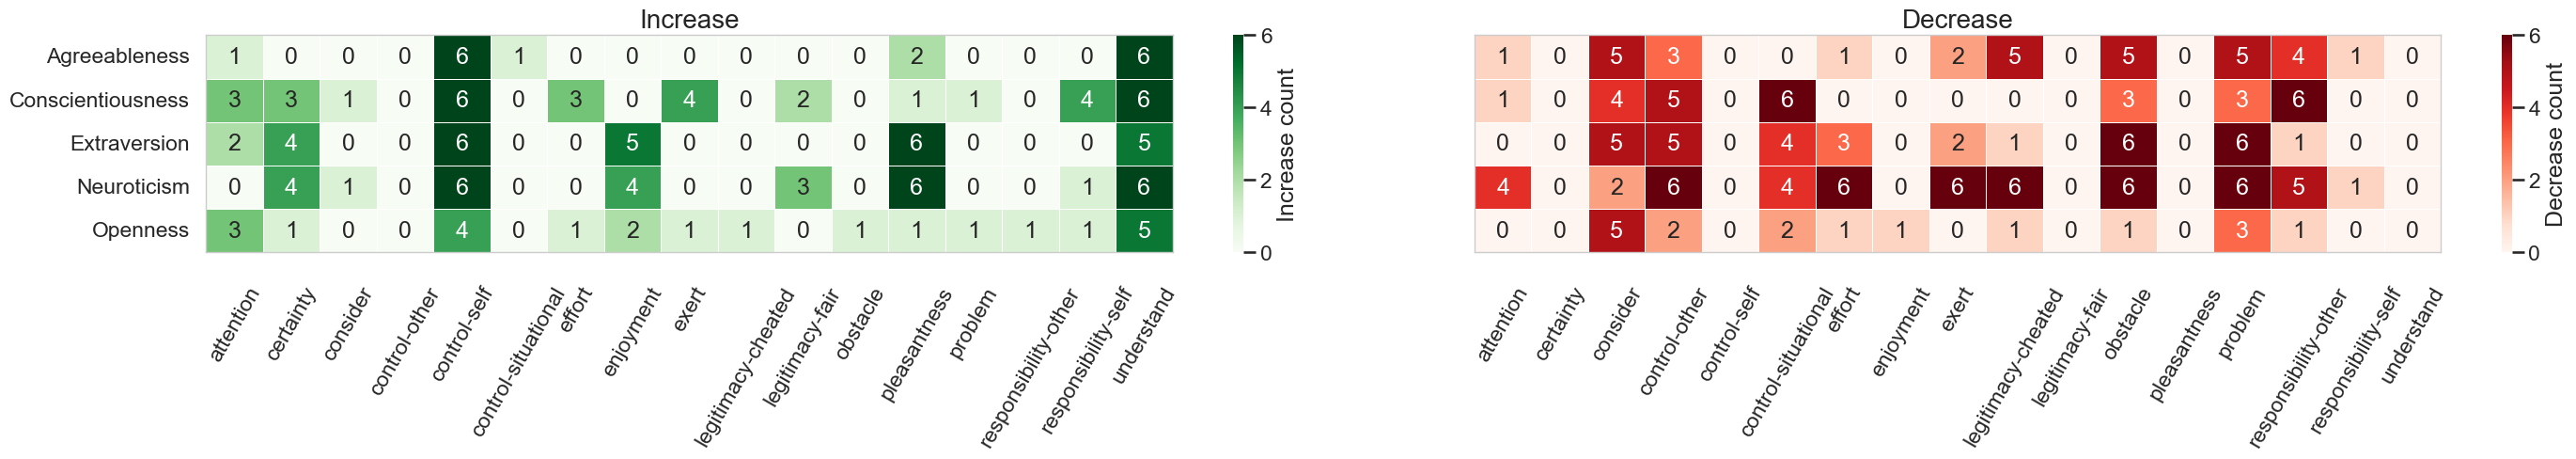

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build increase matrix (personas x dimensions)
inc_df = pd.DataFrame({
    persona: data["increase"]
    for persona, data in result_dict_positive_persona.items()
}).T

# Build decrease matrix (personas x dimensions)
dec_df = pd.DataFrame({
    persona: data["decrease"]
    for persona, data in result_dict_positive_persona.items()
}).T

# Ensure same ordering
dims = sorted(set(inc_df.columns) | set(dec_df.columns))
personas = sorted(set(inc_df.index) | set(dec_df.index))

inc_df = inc_df.reindex(index=personas, columns=dims).fillna(0).astype(int)
dec_df = dec_df.reindex(index=personas, columns=dims).fillna(0).astype(int)

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(
    1, 2,
    figsize=(1.0 * len(dims) * 2, 0.6 * len(personas)),
    sharey=True,
    gridspec_kw={"wspace": 0.05}  # small gap = “divider”
)

# Left: increases
sns.heatmap(
    inc_df,
    ax=axes[0],
    cmap="Greens",
    annot=True,
    fmt="d",
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Increase count"}
)
axes[0].set_title("Increase", fontsize=20)
# axes[0].set_xlabel("Appraisal dimension")
# axes[0].set_ylabel("Persona")
axes[0].tick_params(axis="x", rotation=60, size=20)

# Right: decreases
sns.heatmap(
    dec_df,
    ax=axes[1],
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Decrease count"}
)
axes[1].set_title("Decrease", fontsize=20)
# axes[1].set_xlabel("Appraisal dimension")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=60, size=20)

# Optional: make the split more visible (a vertical line between panels)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)

plt.tight_layout()
plt.savefig("./positive_persona_impact.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [67]:
result_dict_negative_persona = get_impact_of_personas(negative_personas, persona_names, negative_suffix)

Model: GPT o4-mini
-----------------------------------------
-----------------------------------------
Analysis for Agreeableness-Low

pleasantness: No significant difference with persona.
enjoyment: No significant difference with persona.
consider: Persona > Vanilla
attention: Vanilla > Persona
understand: Persona > Vanilla
control-situational: Vanilla > Persona
control-self: Persona > Vanilla
control-other: Vanilla > Persona
certainty: Persona > Vanilla
problem: No significant difference with persona.
obstacle: Vanilla > Persona
legitimacy-cheated: Persona > Vanilla
legitimacy-fair: Vanilla > Persona
responsibility-self: Vanilla > Persona
responsibility-other: Persona > Vanilla
exert: Vanilla > Persona
effort: Vanilla > Persona
-----------------------------------------
Analysis for Conscientiousness-Low

pleasantness: No significant difference with persona.
enjoyment: No significant difference with persona.
consider: Persona > Vanilla
attention: Vanilla > Persona
understand: Vanilla 

In [68]:
result_dict_negative_persona

{'Agreeableness': {'increase': {'pleasantness': 3,
   'enjoyment': 2,
   'consider': 6,
   'attention': 0,
   'understand': 4,
   'control-situational': 0,
   'control-self': 5,
   'control-other': 1,
   'certainty': 2,
   'problem': 0,
   'obstacle': 0,
   'legitimacy-cheated': 3,
   'legitimacy-fair': 0,
   'responsibility-self': 0,
   'responsibility-other': 3,
   'exert': 1,
   'effort': 0},
  'decrease': {'pleasantness': 0,
   'enjoyment': 1,
   'consider': 0,
   'attention': 5,
   'understand': 1,
   'control-situational': 6,
   'control-self': 1,
   'control-other': 5,
   'certainty': 0,
   'problem': 3,
   'obstacle': 5,
   'legitimacy-cheated': 2,
   'legitimacy-fair': 6,
   'responsibility-self': 6,
   'responsibility-other': 2,
   'exert': 5,
   'effort': 6}},
 'Conscientiousness': {'increase': {'pleasantness': 1,
   'enjoyment': 1,
   'consider': 6,
   'attention': 0,
   'understand': 0,
   'control-situational': 4,
   'control-self': 0,
   'control-other': 4,
   'certainty

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_50312/2056347366.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


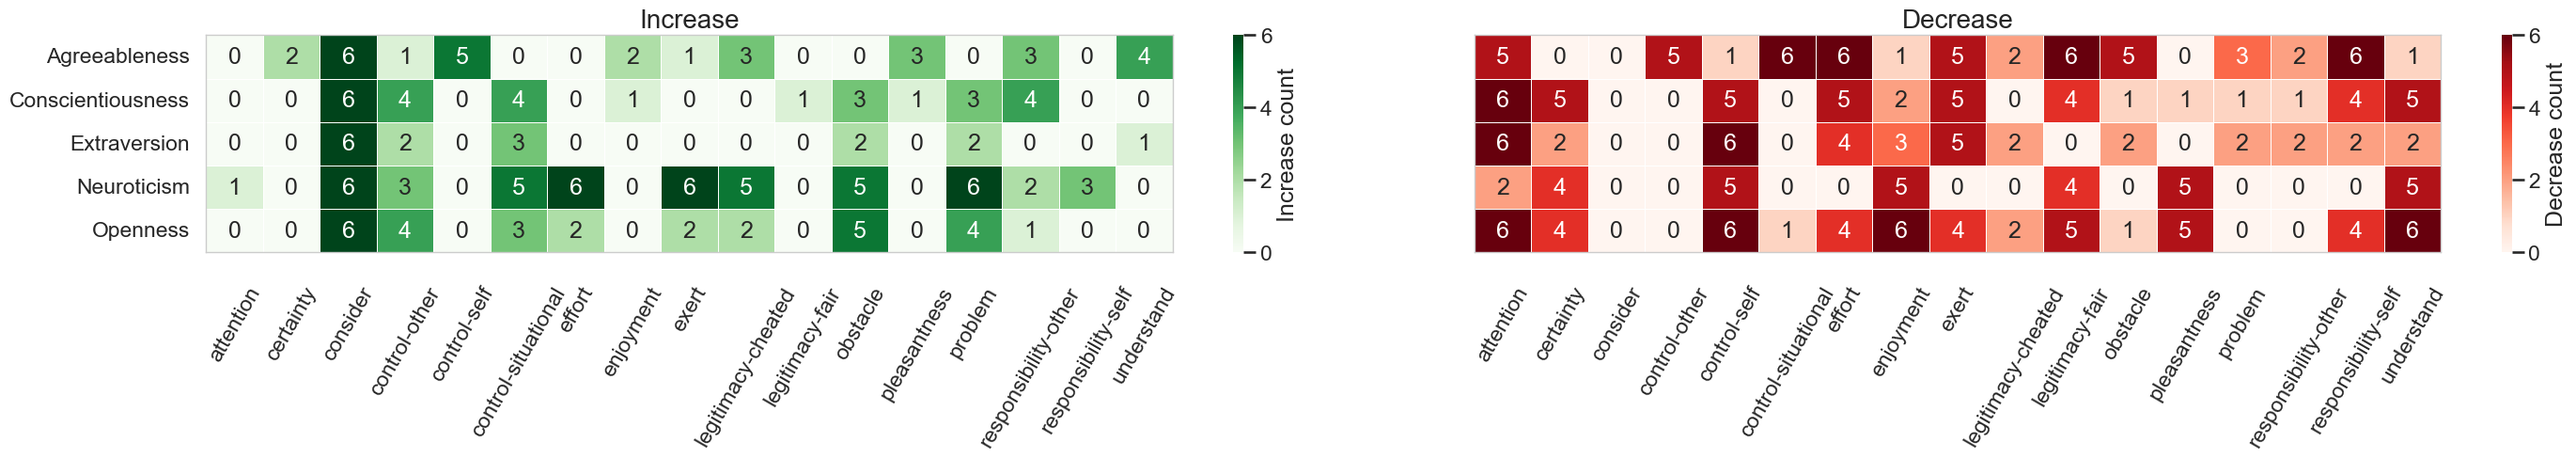

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build increase matrix (personas x dimensions)
inc_df = pd.DataFrame({
    persona: data["increase"]
    for persona, data in result_dict_negative_persona.items()
}).T

# Build decrease matrix (personas x dimensions)
dec_df = pd.DataFrame({
    persona: data["decrease"]
    for persona, data in result_dict_negative_persona.items()
}).T

# Ensure same ordering
dims = sorted(set(inc_df.columns) | set(dec_df.columns))
personas = sorted(set(inc_df.index) | set(dec_df.index))

inc_df = inc_df.reindex(index=personas, columns=dims).fillna(0).astype(int)
dec_df = dec_df.reindex(index=personas, columns=dims).fillna(0).astype(int)

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(
    1, 2,
    figsize=(1.0 * len(dims) * 2, 0.6 * len(personas)),
    sharey=True,
    gridspec_kw={"wspace": 0.05}  # small gap = “divider”
)

# Left: increases
sns.heatmap(
    inc_df,
    ax=axes[0],
    cmap="Greens",
    annot=True,
    fmt="d",
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Increase count"}
)
axes[0].set_title("Increase", fontsize=20)
# axes[0].set_xlabel("Appraisal dimension")
# axes[0].set_ylabel("Persona")
axes[0].tick_params(axis="x", rotation=60, size=20)

# Right: decreases
sns.heatmap(
    dec_df,
    ax=axes[1],
    cmap="Reds",
    annot=True,
    fmt="d",
    linewidths=0.4,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Decrease count"}
)
axes[1].set_title("Decrease", fontsize=20)
# axes[1].set_xlabel("Appraisal dimension")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=60, size=20)

# Optional: make the split more visible (a vertical line between panels)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)

plt.tight_layout()
plt.savefig("./negative_persona_impact.pdf", format="pdf", bbox_inches="tight")
plt.show()
